# FP Feature Analysis — Distribution Plots (positive = "malware")

Visualization of selected features distribute across **benign (0)** vs **malware (1)** in the **original dataset**.

- Input: a labeled table with a `label` column (values either `{"benign","malware"}` or `{0,1}`).
- Output: multi-panel grid of overlaid histograms (density) for each selected feature, plus a CSV of summary stats.
- Notes: no log scales; same binning/range per feature across both classes.

**Feature set (Top 15 by mean positive contribution on FPs)**

`[
"ip_a_aaaa_to_all_ratio", "dns_NS_count", "rdap_ip_v4_count", "rdap_domain_age",
"lex_sub_count", "lex_tld_abuse_score", "rdap_domain_active_time", "ip_as_address_entropy",
"rdap_registrar_name_len", "rdap_registration_period", "dns_ttl_stdev",
"tls_CA_certs_in_chain_ratio", "lex_stdev_part_lens", "ip_asn_entropy", "rdap_admin_name_len"
]`


## 1. Parameters

In [6]:
# ==== EDIT THESE IF NEEDED ====
DATA_PATH     = "dataframes/malware_df_fp_tuning.csv"   # Parquet (preferred) or CSV
LABEL_COL     = "label"
TARGET_MAP    = {"benign": 0, "malware": 1}          # if labels are strings
ID_COLS       = ["domain_name"]                      # drop from features if present
FEATURES = [
    "ip_a_aaaa_to_all_ratio", "dns_NS_count", "rdap_ip_v4_count", "rdap_domain_age",
    "lex_sub_count", "lex_tld_abuse_score", "rdap_domain_active_time", "ip_as_address_entropy",
    "rdap_registrar_name_len", "rdap_registration_period", "dns_ttl_stdev",
    "tls_CA_certs_in_chain_ratio", "lex_stdev_part_lens", "ip_asn_entropy", "rdap_admin_name_len",
]
ARTIF_DIR = "artifacts_dist_original"
BINS_PER_FEATURE = 50


## 2. Imports

In [2]:
import os
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import joblib
import matplotlib.pyplot as plt

from typing import List, Optional
from sklearn.metrics import confusion_matrix
plt.rcParams["figure.dpi"] = 120
os.makedirs(ARTIF_DIR, exist_ok=True)


## 3. Utilities (helpers)

In [7]:
def load_table(path: str) -> pd.DataFrame:
    if path.lower().endswith((".parquet", ".pq")):
        return pd.read_parquet(path)
    elif path.lower().endswith(".csv"):
        return pd.read_csv(path)
    else:
        # try parquet, then csv
        try:
            return pd.read_parquet(path)
        except Exception:
            return pd.read_csv(path)

def coerce_label(series: pd.Series) -> pd.Series:
    # If already 0/1, return; else map strings via TARGET_MAP
    if pd.api.types.is_numeric_dtype(series):
        # Make sure it’s {0,1}
        uniq = set(pd.unique(series.dropna()))
        if uniq.issubset({0,1}):
            return series.astype("int8")
    # Map strings -> ints
    mapped = series.map(TARGET_MAP)
    if mapped.isna().any():
        missing = series[pd.isna(mapped)].unique()[:10]
        raise ValueError(f"Unmapped label values found: {missing}. Update TARGET_MAP.")
    return mapped.astype("int8")


## 4. Load the original dataset & build X/y

In [8]:
df = load_table(DATA_PATH).copy()
if LABEL_COL not in df.columns:
    raise ValueError(f"Label column '{LABEL_COL}' not found in dataset. Columns: {list(df.columns)[:20]}...")

df[LABEL_COL] = coerce_label(df[LABEL_COL])
y = df[LABEL_COL].values  # 0=benign, 1=malware

# Features = drop label + ids; keep numeric columns only
drop_cols = [LABEL_COL] + [c for c in ID_COLS if c in df.columns]
X_all = df.drop(columns=drop_cols, errors="ignore").copy()
numeric_cols = X_all.select_dtypes(include=[np.number]).columns.tolist()

# Keep only requested FEATURES that exist & are numeric; warn on skips
features_present = [f for f in FEATURES if f in numeric_cols]
features_skipped = [f for f in FEATURES if f not in features_present]
if features_skipped:
    print("[info] Skipping missing/non-numeric features:", features_skipped)

X = X_all[features_present]
print(f"Dataset shape: {df.shape}, Benign={int((y==0).sum())}, Malware={int((y==1).sum())}")
print(f"Using {len(features_present)} features for plots.")


Dataset shape: (917133, 174), Benign=816324, Malware=100809
Using 15 features for plots.


Total: 917,133
Benign:  816,324  (89.01%)
Malware: 100,809  (10.99%)


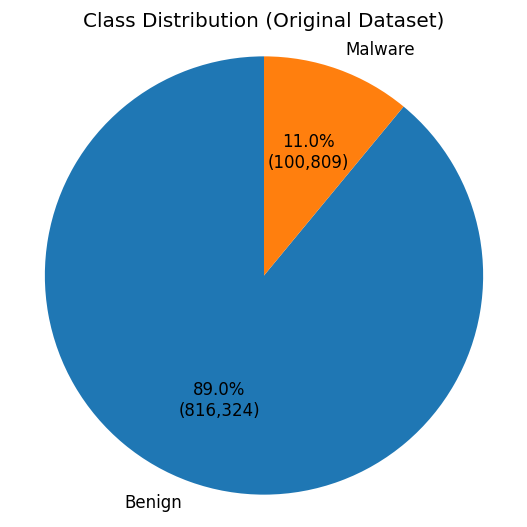

In [20]:
# Counts & optional pie chart for benign vs malware in the ORIGINAL dataset
# --- choose your label source ---
# If you already have y as 0/1:
label_series = pd.Series(y) if 'y' in globals() else df[LABEL_COL]

# Normalize to strings for display
def to_str_label(v):
    if isinstance(v, (int, np.integer)):
        return "benign" if v == 0 else "malware"
    return str(v)

labels_str = label_series.map(to_str_label)

# Compute counts and percentages
counts = labels_str.value_counts().reindex(["benign", "malware"], fill_value=0)
total = int(counts.sum())
ben, mal = int(counts.get("benign", 0)), int(counts.get("malware", 0))
pct_ben = (ben / total * 100) if total else 0.0
pct_mal = (mal / total * 100) if total else 0.0

print(f"Total: {total:,}")
print(f"Benign:  {ben:,}  ({pct_ben:.2f}%)")
print(f"Malware: {mal:,}  ({pct_mal:.2f}%)")

# ---- Optional pie chart ----
show_pie = True  # set to False if you only want numbers
if show_pie:
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    wedges, texts, autotexts = ax.pie(
        [ben, mal],
        labels=["Benign", "Malware"],
        autopct=lambda p: f"{p:.1f}%\n({int(round(p*total/100)):,})",
        startangle=90
    )
    ax.axis("equal")  # equal aspect ratio for a circle
    ax.set_title("Class Distribution (Original Dataset)")
    plt.tight_layout()
    plt.show()


## 6. Plot distributions

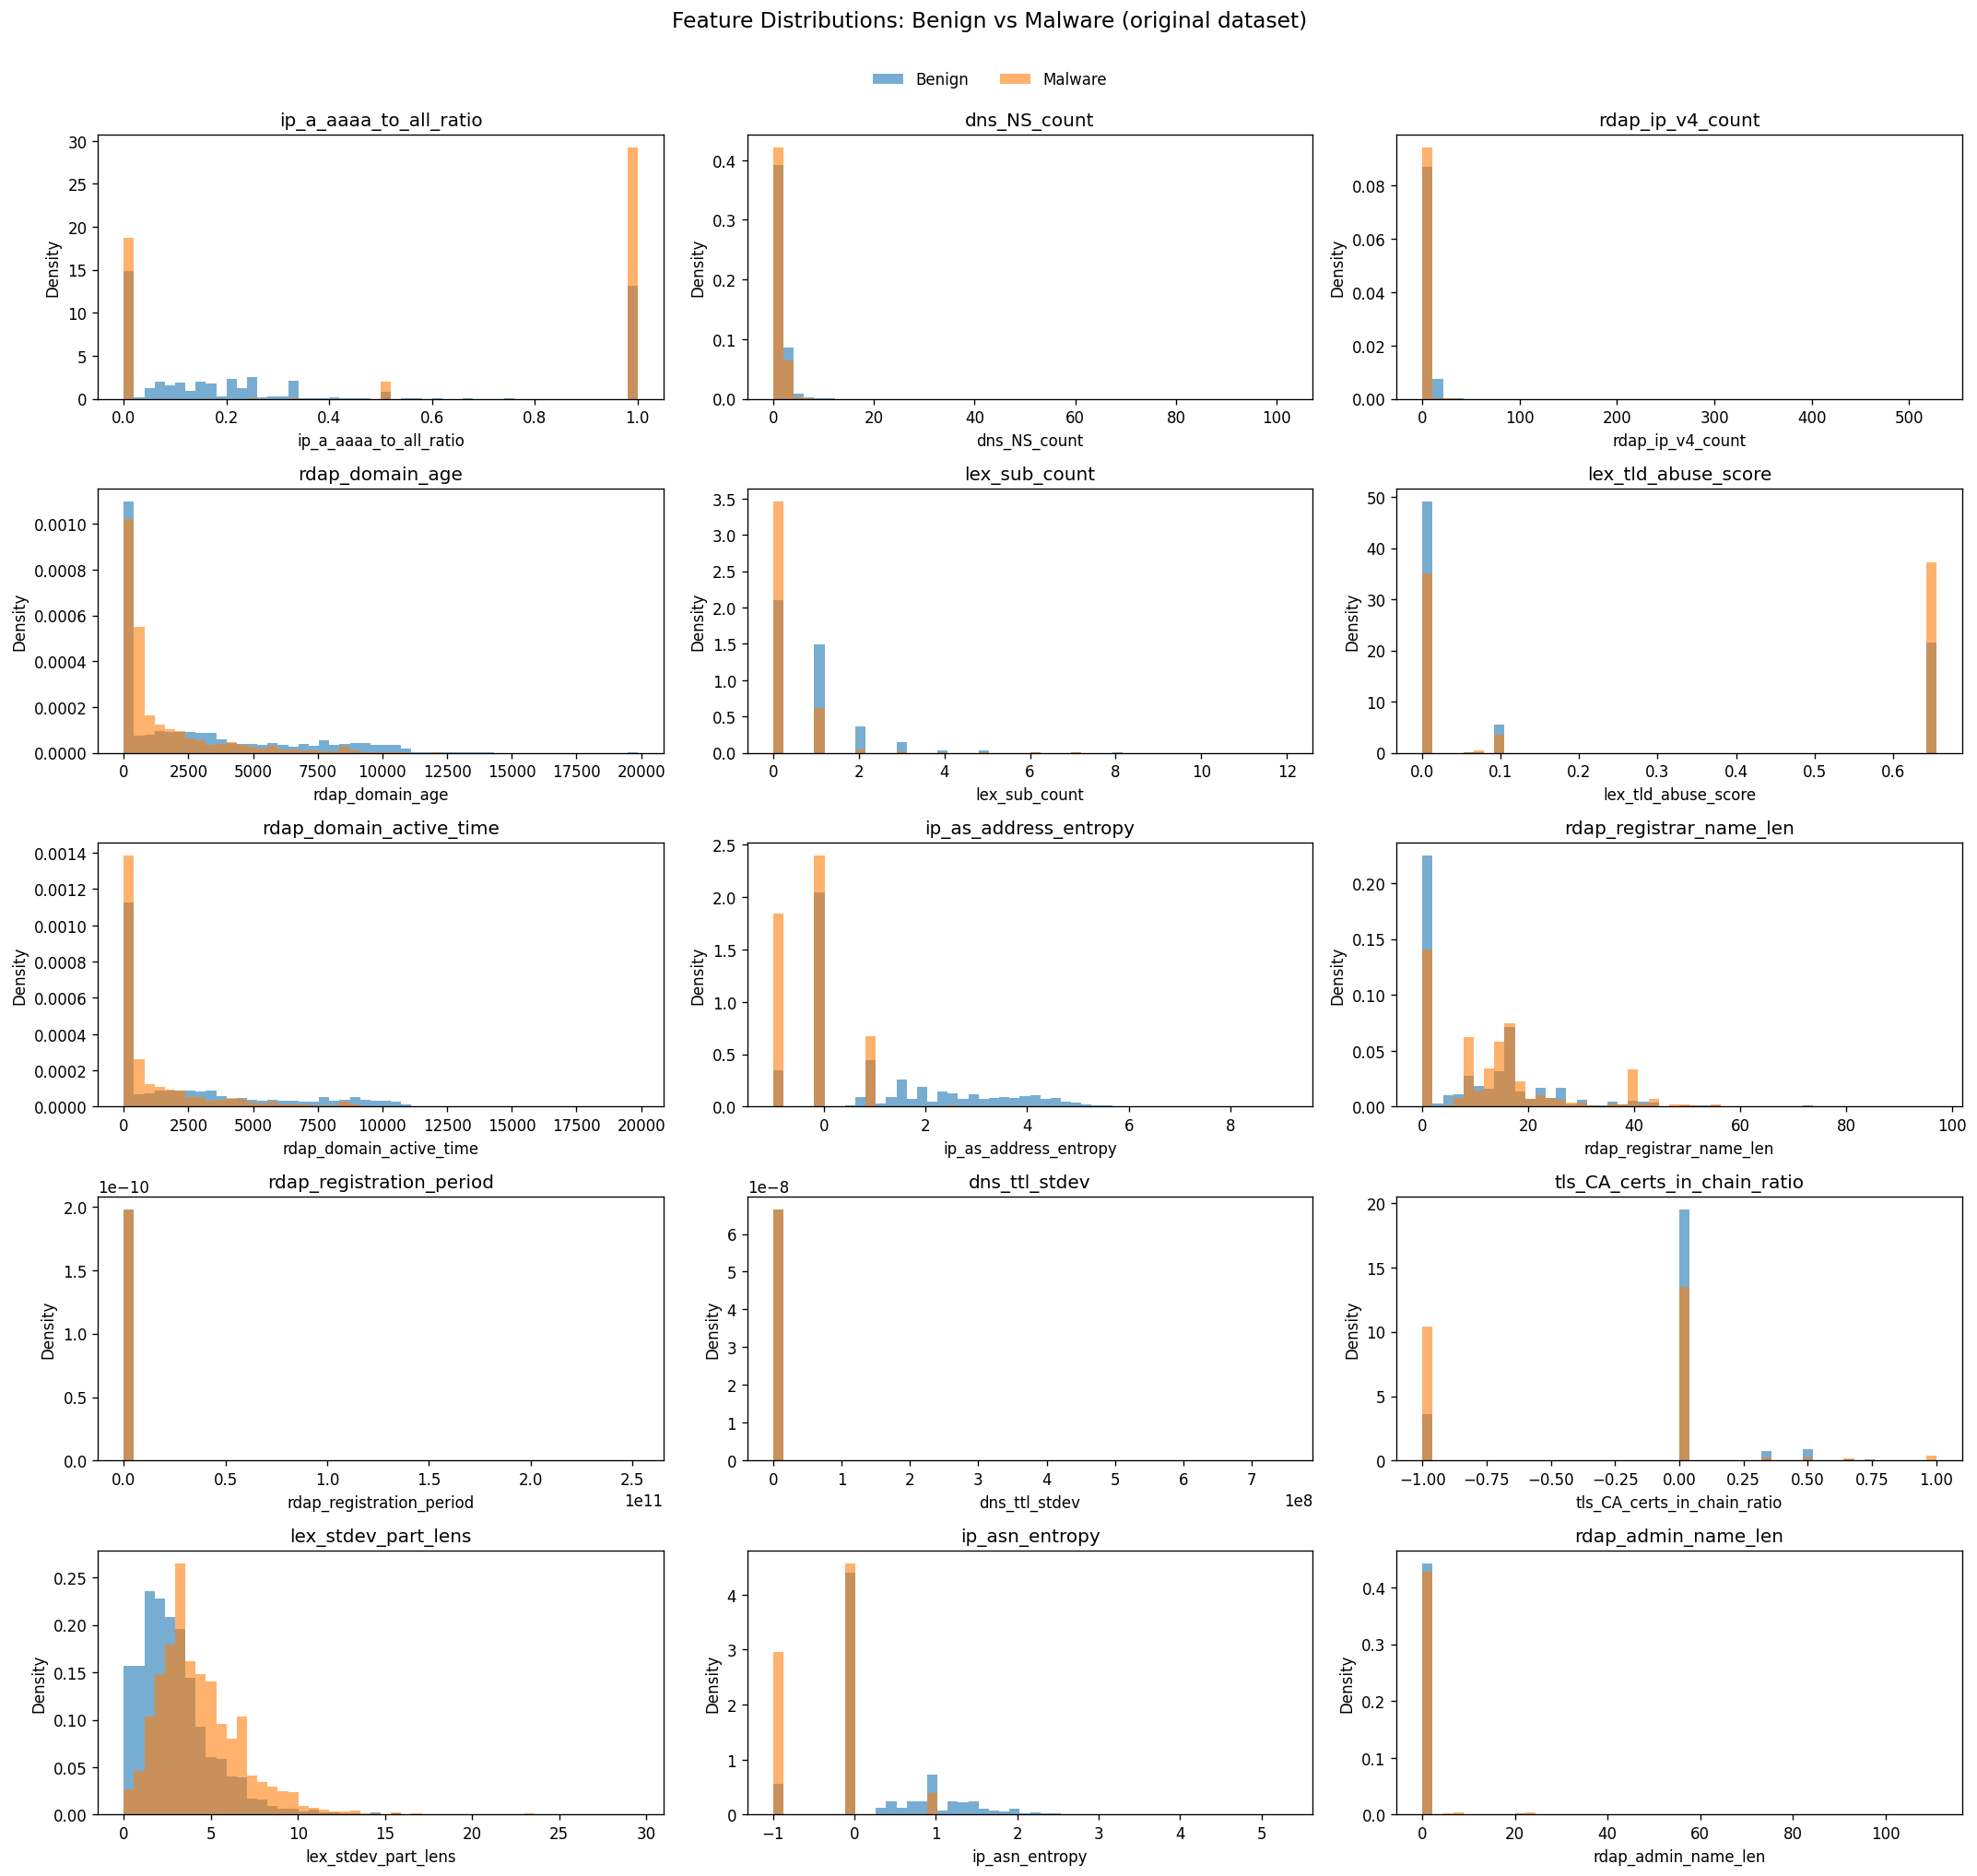

,feature,benign_count,benign_mean,benign_std,benign_p5,benign_p50,benign_p95,malware_count,malware_mean,malware_std,malware_p5,malware_p50,malware_p95
0,ip_a_aaaa_to_all_ratio,816324,0.347829,0.404578,0.0,0.166667,1.000000,100809,0.605259,0.478187,0.0,1.000000,1.000000
1,dns_NS_count,816324,1.326587,1.659436,0.0,0.000000,4.000000,100809,1.231864,1.413022,0.0,0.000000,4.000000
2,rdap_ip_v4_count,816324,4.274261,4.163045,0.0,3.000000,12.000000,100809,1.198197,1.906497,0.0,1.000000,4.000000
3,rdap_domain_age,816324,2642.126813,3308.567038,-1.0,1221.000000,9646.791667,100809,1327.833311,1938.838587,-1.0,514.827674,5815.166667
4,lex_sub_count,816324,0.710100,0.926711,0.0,0.000000,3.000000,100809,0.212431,0.589819,0.0,0.000000,1.000000


In [18]:
# Masks
benign_mask  = (y == 0)
malware_mask = (y == 1)

n_feats = len(features_present)
n_cols = 3
n_rows = int(np.ceil(n_feats / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3.4 * n_rows))
axes = np.atleast_2d(axes)
axes_flat = axes.ravel()

summary_rows = []

for i, feat in enumerate(features_present):
    ax = axes_flat[i]
    s = pd.to_numeric(X[feat], errors="coerce").replace([np.inf, -np.inf], np.nan)

    s_ben = s[benign_mask].dropna()
    s_mal = s[malware_mask].dropna()

    # Shared range & bins
    finite_all = s.dropna().values
    if finite_all.size == 0:
        ax.set_title(f"{feat} (no finite data)")
        ax.axis("off")
        continue
    data_min, data_max = float(np.nanmin(finite_all)), float(np.nanmax(finite_all))
    if data_min == data_max:
        data_max = data_min + 1e-9

    ax.hist(s_ben.values, bins=BINS_PER_FEATURE, range=(data_min, data_max),
            alpha=0.6, density=True, label="Benign")
    ax.hist(s_mal.values, bins=BINS_PER_FEATURE, range=(data_min, data_max),
            alpha=0.6, density=True, label="Malware")

    ax.set_title(feat)
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")

    # Stats for CSV
    def stats(x):
        x = pd.Series(x).dropna()
        if x.empty:
            return dict(count=0, mean=np.nan, std=np.nan, p5=np.nan, p50=np.nan, p95=np.nan)
        return dict(
            count=int(x.size),
            mean=float(x.mean()),
            std=float(x.std(ddof=1)) if x.size > 1 else 0.0,
            p5=float(np.percentile(x, 5)),
            p50=float(np.percentile(x, 50)),
            p95=float(np.percentile(x, 95)),
        )
    st_b = stats(s_ben); st_m = stats(s_mal)
    summary_rows.append({
        "feature": feat,
        **{f"benign_{k}": v for k,v in st_b.items()},
        **{f"malware_{k}": v for k,v in st_m.items()},
    })

# Hide any unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# One legend for the figure
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.97))

fig.suptitle("Feature Distributions: Benign vs Malware (original dataset)", y=0.995, fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

# Save summary table
summary_df = pd.DataFrame(summary_rows)
summary_df.head()


/tmp/ipykernel_243773/1994728509.py:90: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.90)


Saved figure: artifacts_dist_original/dist_grid_benign_vs_malware_clean.png


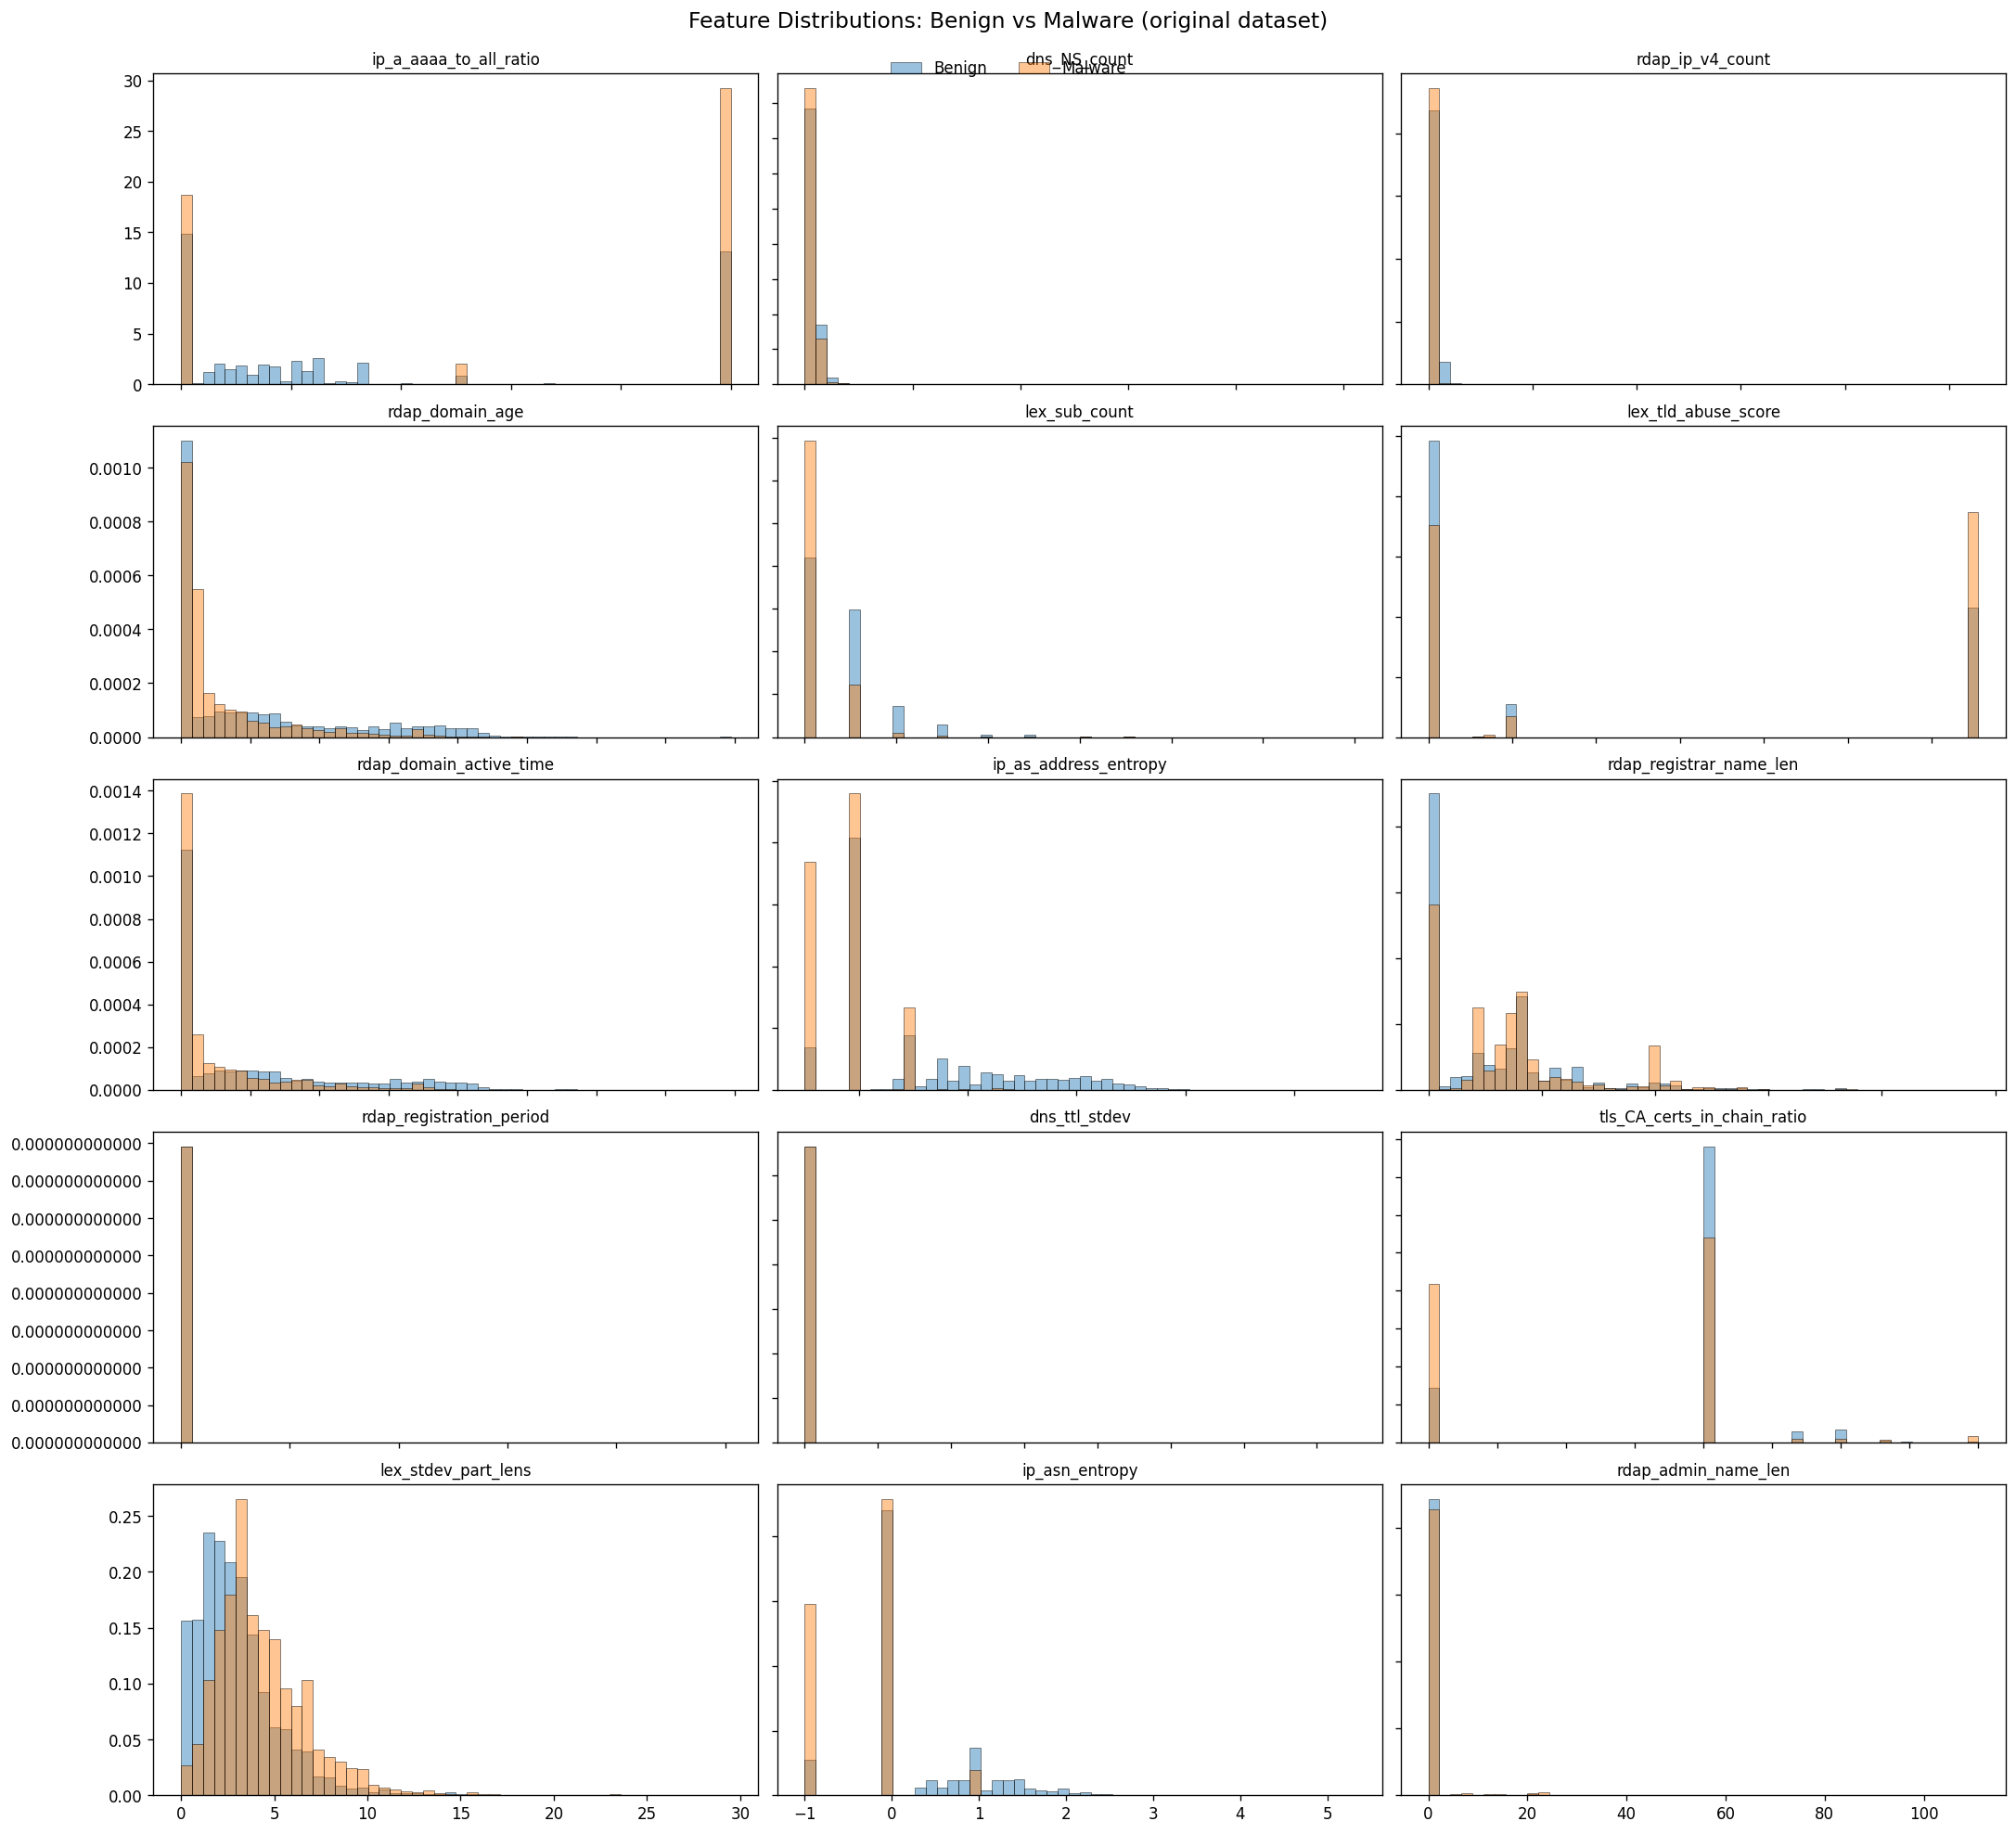

In [13]:
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

ARTIF_DIR = "artifacts_dist_original"
os.makedirs(ARTIF_DIR, exist_ok=True)

# Masks for original dataset (not benign-only)
benign_mask  = (y == 0)
malware_mask = (y == 1)

features_present = FEATURES  # or your computed list

n_feats = len(features_present)
n_cols = 3
n_rows = int(np.ceil(n_feats / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(18, 3.2 * n_rows),
    constrained_layout=True  # lets Matplotlib manage spacing well
)
axes = np.atleast_2d(axes)
axes_flat = axes.ravel()

# We'll capture handles/labels from the first plotted axis for a single figure legend
legend_handles = None
legend_labels  = None

for i, feat in enumerate(features_present):
    ax = axes_flat[i]
    if feat not in X.columns:
        ax.set_title(f"{feat} (missing)")
        ax.axis("off")
        continue

    s = pd.to_numeric(X[feat], errors="coerce").replace([np.inf, -np.inf], np.nan)
    s_ben = s[benign_mask].dropna()
    s_mal = s[malware_mask].dropna()

    finite_all = s.dropna().values
    if finite_all.size == 0:
        ax.set_title(f"{feat} (no finite data)")
        ax.axis("off")
        continue

    data_min, data_max = float(np.nanmin(finite_all)), float(np.nanmax(finite_all))
    if data_min == data_max:
        data_max = data_min + 1e-9
    bins = 50

    # Plot Benign first (often larger), then Malware; add outlines for visibility
    h1 = ax.hist(
        s_ben.values, bins=bins, range=(data_min, data_max),
        alpha=0.45, density=True, label="Benign", edgecolor="black", linewidth=0.6
    )
    h2 = ax.hist(
        s_mal.values, bins=bins, range=(data_min, data_max),
        alpha=0.45, density=True, label="Malware", edgecolor="black", linewidth=0.6
    )

    # Collect legend only once
    if legend_handles is None:
        legend_handles, legend_labels = ax.get_legend_handles_labels()

    ax.set_title(feat, fontsize=10)

    # Make y-axis labels plain (no 1e-8 scientific notation)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=False))
    ax.ticklabel_format(axis="y", style="plain")

# Hide any unused axes
for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

# Only bottom-row x labels and left-column y labels to reduce clutter
for r in range(n_rows):
    for c in range(n_cols):
        ax = axes[r, c]
        if r < n_rows - 1:  # not bottom row
            ax.set_xlabel("")
            ax.tick_params(labelbottom=False)
        if c > 0:  # not left column
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

# Figure title and legend (placed clearly above, no overlap)
fig.suptitle("Feature Distributions: Benign vs Malware (original dataset)", fontsize=14, y=1.02)
fig.legend(legend_handles, legend_labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.0))

# Small top margin so legend + title breathe
fig.subplots_adjust(top=0.90)

out_path = os.path.join(ARTIF_DIR, "dist_grid_benign_vs_malware_clean.png")
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Saved figure: {out_path}")
plt.show()
